In [2]:
from pathlib import Path
import sys
import numpy as np

# Add mast3r repo to path so internal absolute imports work
MAST3R_REPO_PATH = Path("/home/hugues/Documents/mee-deepreefmap/mast3r")
if str(MAST3R_REPO_PATH) not in sys.path:
    sys.path.insert(0, str(MAST3R_REPO_PATH))

# dust3r is nested inside the mast3r submodule
DUST3R_PATH = MAST3R_REPO_PATH / "dust3r"
if str(DUST3R_PATH) not in sys.path:
    sys.path.insert(0, str(DUST3R_PATH))

# Add src to path for local imports
SRC_PATH = Path("/home/hugues/Documents/mee-deepreefmap/src")
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# ── Configure input/output paths ──────────────────────────────────────
output_fw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/2024_Sunrise_fw_leg"
)
output_bw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/exp_israel-eilat_fwbw_rec/2024_Sunrise_bw_leg"
)

poses_fw = np.load(output_fw_dir / "poses.npy")
intrinsics_fw = np.load(output_fw_dir / "intrinsics.npy")
frames_fw = sorted(output_fw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

poses_bw = np.load(output_bw_dir / "poses.npy")
intrinsics_bw = np.load(output_bw_dir / "intrinsics.npy")
frames_bw = sorted(output_bw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

N_fw = len(frames_fw)
N_bw = len(frames_bw)
print(f"Forward:  {N_fw} frames, poses {poses_fw.shape}")
print(f"Backward: {N_bw} frames, poses {poses_bw.shape}")

Forward:  1160 frames, poses (1160, 4, 4)
Backward: 890 frames, poses (890, 4, 4)


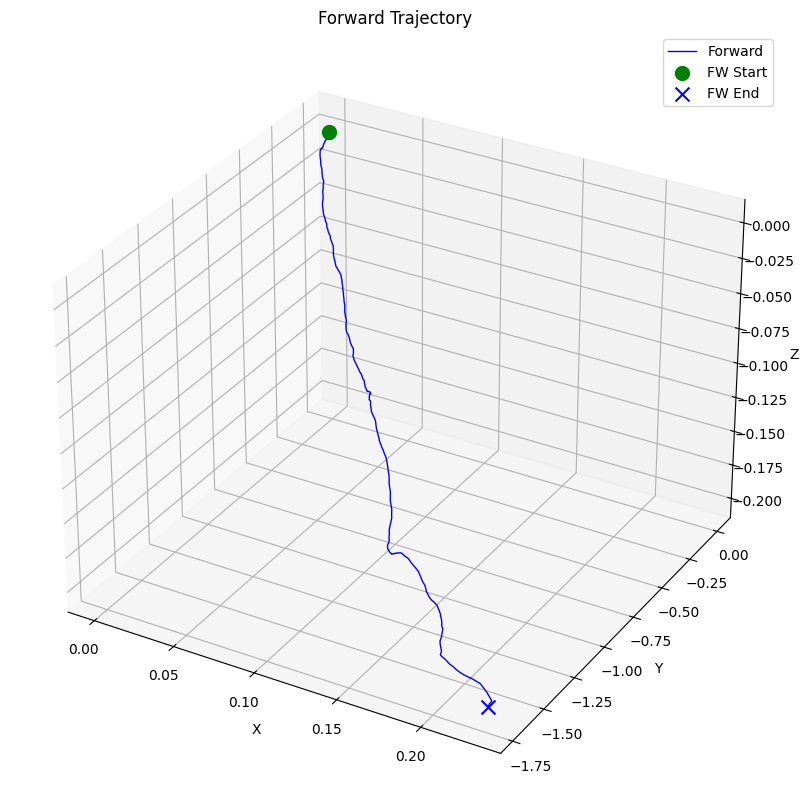

Text(0.5, 0.92, 'Backward Trajectory')

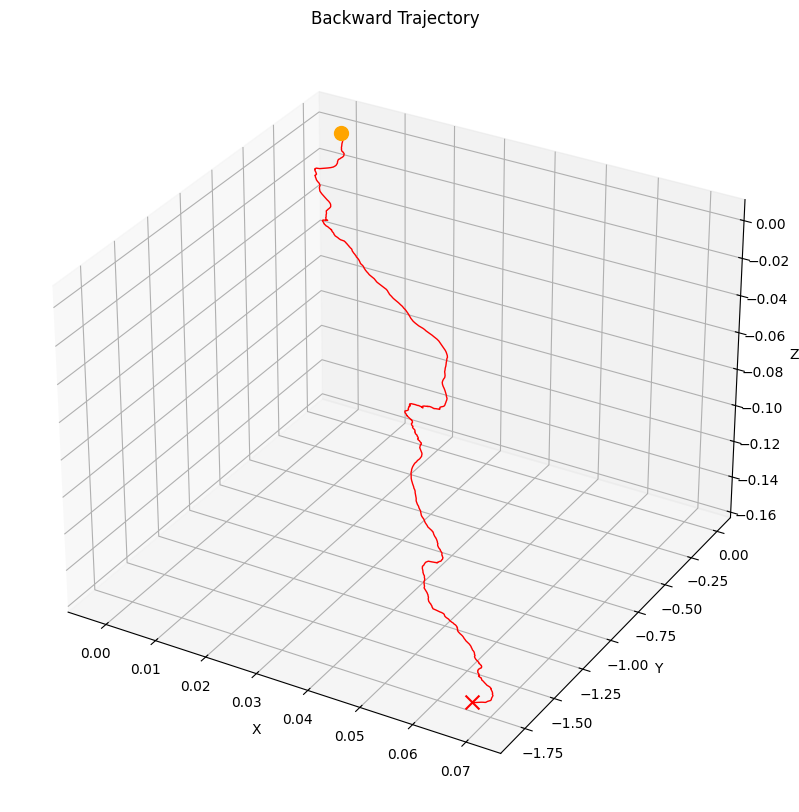

In [ ]:
# visualize the poses in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract camera positions from pose matrices (translation component)
# Pose matrices are 4x4, translation is the last column [:3, 3]
positions_fw = poses_fw[:, :3, 3]
positions_bw = poses_bw[:, :3, 3]

# Plot forward trajectory
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
ax.plot(
    positions_fw[:, 0], positions_fw[:, 1], positions_fw[:, 2], "b-", label="Forward", linewidth=1
)
ax.scatter(
    positions_fw[0, 0],
    positions_fw[0, 1],
    positions_fw[0, 2],
    c="green",
    s=100,
    marker="o",
    label="FW Start",
)
ax.scatter(
    positions_fw[-1, 0],
    positions_fw[-1, 1],
    positions_fw[-1, 2],
    c="blue",
    s=100,
    marker="x",
    label="FW End",
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Forward Trajectory")
ax.legend()
plt.show()

# Plot backward trajectory
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
ax.plot(
    positions_bw[:, 0], positions_bw[:, 1], positions_bw[:, 2], "r-", label="Backward", linewidth=1
)
ax.scatter(
    positions_bw[0, 0],
    positions_bw[0, 1],
    positions_bw[0, 2],
    c="orange",
    s=100,
    marker="o",
    label="BW Start",
)
ax.scatter(
    positions_bw[-1, 0],
    positions_bw[-1, 1],
    positions_bw[-1, 2],
    c="red",
    s=100,
    marker="x",
    label="BW End",
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Backward Trajectory")
ax.legend()
plt.show()
plt.show()

# Plot backward trajectory
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
ax.plot(
    positions_bw[:, 0], positions_bw[:, 1], positions_bw[:, 2], "r-", label="Backward", linewidth=1
)
ax.scatter(
    positions_bw[0, 0],
    positions_bw[0, 1],
    positions_bw[0, 2],
    c="orange",
    s=100,
    marker="o",
    label="BW Start",
)
ax.scatter(
    positions_bw[-1, 0],
    positions_bw[-1, 1],
    positions_bw[-1, 2],
    c="red",
    s=100,
    marker="x",
    label="BW End",
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Backward Trajectory")